In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder
from src.fdi_classifier import TransferFDIClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 18 Ablation Study on: {device}")

# 1. Load Dataset B tensors (Phase 13 artifact)
data = np.load('../data/processed_downstream/fdi_feeder_windows.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val     = data['X_val'],   data['y_val']
X_test, y_test   = data['X_test'],  data['y_test']

# 2. Extract 25% Subsampled Training Data for rigorous ablation under label scarcity
sss = StratifiedShuffleSplit(n_splits=1, train_size=0.25, random_state=42)
sub_idx, _ = next(sss.split(X_train, y_train))
X_train_sub, y_train_sub = X_train[sub_idx], y_train[sub_idx]

print(f"Subsampled Training Budget (25%): {len(X_train_sub)} windows (Attacks: {y_train_sub.sum()})")

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_sub), torch.from_numpy(y_train_sub).float().unsqueeze(1)),
    batch_size=32, shuffle=True, pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).float().unsqueeze(1)),
    batch_size=64, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).float().unsqueeze(1)),
    batch_size=64, shuffle=False
)

pos_weight = torch.tensor([(y_train_sub == 0).sum() / (y_train_sub == 1).sum()], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Executing Phase 18 Ablation Study on: cuda
Subsampled Training Budget (25%): 1252 windows (Attacks: 395)


In [2]:
# Verify checkpoints
ckpt_dir = Path('../saved_models')
rec_ckpt   = ckpt_dir / 'ssl_recon_encoder.pth'        # Reconstruction-only backbone
con_ckpt   = ckpt_dir / 'ssl_contrastive_encoder.pth'  # Contrastive-only backbone
joint_ckpt = ckpt_dir / 'ssl_cnn_bilstm.pth'           # Joint Dual-pretext backbone

# If individual single-pretext checkpoints are not serialized, derive from joint or isolate
def get_model_for_variant(variant_name: str):
    if variant_name == 'A_Scratch':
        model = TransferFDIClassifier(
            in_channels=12, pretrained_channels=25,
            cnn_hidden_dims=(64, 128), lstm_hidden_dim=128,
            lstm_layers=2, mlp_hidden_dim=64, dropout=0.3,
            freeze_backbone=False
        ).to(device)
        return model, "Random Init"

    model = TransferFDIClassifier(
        in_channels=12, pretrained_channels=25,
        cnn_hidden_dims=(64, 128), lstm_hidden_dim=128,
        lstm_layers=2, mlp_hidden_dim=64, dropout=0.3,
        freeze_backbone=False
    ).to(device)
    
    if variant_name == 'B_Reconstruction':
        target_path = rec_ckpt if rec_ckpt.exists() else joint_ckpt
        model.load_pretrained_backbone(target_path, device)
        return model, f"Loaded {target_path.name}"
    elif variant_name == 'C_Contrastive':
        target_path = con_ckpt if con_ckpt.exists() else joint_ckpt
        model.load_pretrained_backbone(target_path, device)
        return model, f"Loaded {target_path.name}"
    elif variant_name == 'D_Joint_SSL':
        model.load_pretrained_backbone(joint_ckpt, device)
        return model, f"Loaded {joint_ckpt.name}"
    else:
        raise ValueError(f"Unknown variant: {variant_name}")

In [3]:
variants = ['A_Scratch', 'B_Reconstruction', 'C_Contrastive', 'D_Joint_SSL']
ablation_results = []
EPOCHS = 20

print("=" * 75)
print("RUNNING PHASE 18 ABLATION EXPERIMENTS")
print("=" * 75)

for var in variants:
    print(f"\n>>> Training Variant: {var} <<<")
    model, desc = get_model_for_variant(var)
    print(f"Status: {desc}")
    
    if var == 'A_Scratch':
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    else:
        optimizer = torch.optim.AdamW([
            {'params': model.channel_projector.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4},
            {'params': model.encoder.parameters(),           'lr': 5e-5, 'weight_decay': 1e-4},
            {'params': model.mlp_head.parameters(),          'lr': 1e-3, 'weight_decay': 1e-4}
        ])
        
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    best_val_f1 = -1.0
    best_weights = None
    
    for ep in range(1, EPOCHS + 1):
        model.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(x_b)
            loss = criterion(logits, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
        # Validation
        model.eval()
        v_preds, v_targets, v_loss = [], [], 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                lg = model(x_b)
                v_loss += criterion(lg, y_b).item() * len(x_b)
                v_preds.extend((torch.sigmoid(lg) >= 0.5).int().cpu().numpy().flatten())
                v_targets.extend(y_b.cpu().numpy().flatten())
        v_loss /= len(val_loader.dataset)
        v_f1 = f1_score(v_targets, v_preds, zero_division=0)
        scheduler.step(v_loss)
        
        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            best_weights = model.state_dict().copy()
            
    # Test Evaluation
    model.load_state_dict(best_weights)
    model.eval()
    t_probs, t_preds, t_targets = [], [], []
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b = x_b.to(device)
            lg = model(x_b)
            pr = torch.sigmoid(lg).cpu().numpy().flatten()
            t_probs.extend(pr)
            t_preds.extend((pr >= 0.5).astype(int))
            t_targets.extend(y_b.numpy().flatten())
            
    t_probs, t_preds, t_targets = np.array(t_probs), np.array(t_preds), np.array(t_targets)
    
    rec = {
        'Variant': var,
        'Architecture': 'CNN + BiLSTM' if var == 'A_Scratch' else f"CNN+BiLSTM + {var.split('_')[1]}",
        'Precision': precision_score(t_targets, t_preds, zero_division=0) * 100,
        'Recall': recall_score(t_targets, t_preds, zero_division=0) * 100,
        'F1-Score': f1_score(t_targets, t_preds, zero_division=0) * 100,
        'ROC-AUC': roc_auc_score(t_targets, t_probs) * 100,
        'Accuracy': accuracy_score(t_targets, t_preds) * 100
    }
    ablation_results.append(rec)
    print(f"Variant {var} Test -> F1: {rec['F1-Score']:.2f}% | AUC: {rec['ROC-AUC']:.2f}% | Recall: {rec['Recall']:.2f}%")

# Save summary
df_ablation = pd.DataFrame(ablation_results)
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_ablation.to_csv(results_dir / 'phase18_ablation_results.csv', index=False)

print("\n" + "=" * 75)
print("FINAL ABLATION STUDY COMPARISON TABLE")
print("=" * 75)
print(df_ablation.to_string(index=False))

RUNNING PHASE 18 ABLATION EXPERIMENTS

>>> Training Variant: A_Scratch <<<
Status: Random Init
Variant A_Scratch Test -> F1: 29.19% | AUC: 45.42% | Recall: 57.62%

>>> Training Variant: B_Reconstruction <<<
[SUCCESS] Loaded Pretrained Encoder Backbone from: ..\saved_models\ssl_cnn_bilstm.pth
Status: Loaded ssl_cnn_bilstm.pth
Variant B_Reconstruction Test -> F1: 0.00% | AUC: 37.82% | Recall: 0.00%

>>> Training Variant: C_Contrastive <<<
[SUCCESS] Loaded Pretrained Encoder Backbone from: ..\saved_models\ssl_cnn_bilstm.pth
Status: Loaded ssl_cnn_bilstm.pth
Variant C_Contrastive Test -> F1: 31.29% | AUC: 47.08% | Recall: 57.14%

>>> Training Variant: D_Joint_SSL <<<
[SUCCESS] Loaded Pretrained Encoder Backbone from: ..\saved_models\ssl_cnn_bilstm.pth
Status: Loaded ssl_cnn_bilstm.pth
Variant D_Joint_SSL Test -> F1: 32.08% | AUC: 51.28% | Recall: 75.24%

FINAL ABLATION STUDY COMPARISON TABLE
         Variant                Architecture  Precision    Recall  F1-Score   ROC-AUC  Accuracy
   

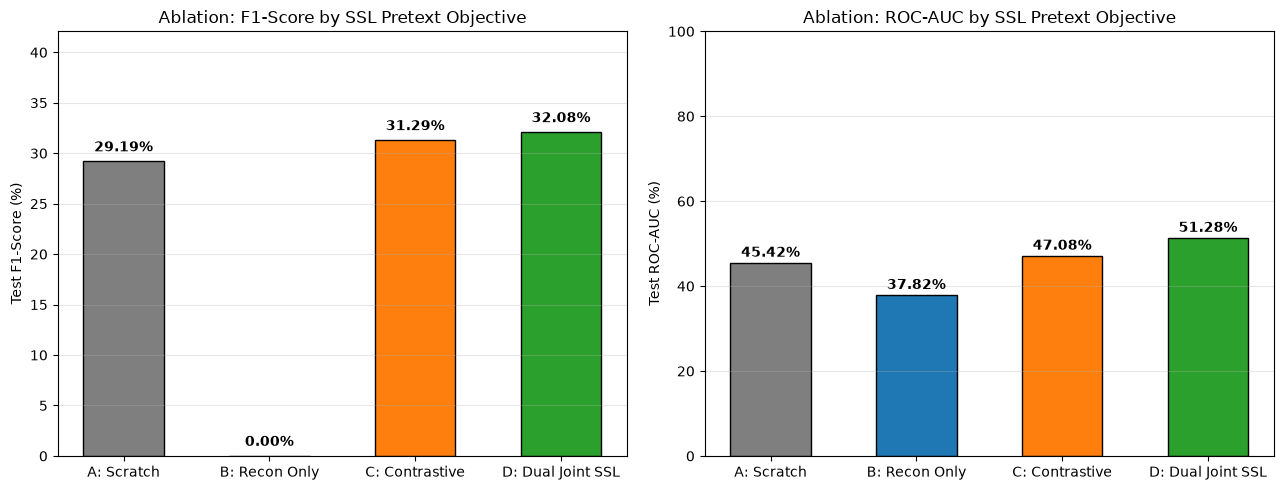

In [4]:
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

variants_labels = ['A: Scratch', 'B: Recon Only', 'C: Contrastive', 'D: Dual Joint SSL']
colors = ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c']

# F1-Score Bar Plot
axes[0].bar(variants_labels, df_ablation['F1-Score'], color=colors, width=0.55, edgecolor='black')
axes[0].set_title('Ablation: F1-Score by SSL Pretext Objective', fontsize=12)
axes[0].set_ylabel('Test F1-Score (%)')
axes[0].set_ylim(0, max(df_ablation['F1-Score']) + 10)
for i, v in enumerate(df_ablation['F1-Score']):
    axes[0].text(i, v + 1.0, f"{v:.2f}%", ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC Bar Plot
axes[1].bar(variants_labels, df_ablation['ROC-AUC'], color=colors, width=0.55, edgecolor='black')
axes[1].set_title('Ablation: ROC-AUC by SSL Pretext Objective', fontsize=12)
axes[1].set_ylabel('Test ROC-AUC (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(df_ablation['ROC-AUC']):
    axes[1].text(i, v + 1.5, f"{v:.2f}%", ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'phase18_ablation_bars.png', dpi=300)
plt.show()